# GSplat Time-Resolved CT — Progressive Sinogram Masking

**Concept:** The SW-FBP baseline (Section 16) works well because it pools projections from neighbouring
time-slices so that each reconstruction uses a full 180° sinogram.  Here we integrate that same idea
into the joint Gaussian-Splatting optimisation (Section 14 style) via a **progressive angular window
schedule**:

| Epoch | Sinogram available for slice *t* |
|-------|----------------------------------|
| 0 | n_win×K_ANGLES projections centered on slice *t* — same 180° coverage as SW-FBP |
| E_anneal | Linearly narrowed to exactly K_ANGLES projections (the true limited-angle acquisition) |
| > E_anneal | Only the K_ANGLES true projections (standard LA training) |

At every epoch and for every slice *t* the active angle indices are a **contiguous block of size
`w(e)`** centered on the midpoint of slice *t*'s true acquisition window, drawn from the ***full***
sinogram of that height row (`la_data.full_sinograms[t]`).  No borrowing from other height rows occurs;
we simply reveal more of the object's own projection data early in training.

**Comparison delivered by this notebook:**
- Ground truth (full-angle FBP)
- FBP-LA (limited angle, K_ANGLES per slice)
- SW-FBP (sliding window, n_win slices, ~180°)
- **Progressive-Mask GSplat** — the new method


## 1. Imports & Setup


In [1]:
import sys, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import optim
from tqdm import tqdm
from skimage.metrics import structural_similarity as _ssim_sk
import lovely_tensors as lt
lt.monkey_patch()
import ipywidgets as widgets
from ipywidgets import interact


# ── Project paths ─────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')

# ── gsplat_compress ───────────────────────────────────────────────────────
from gsplat_compress import (
    GaussianParams, init_gaussians, ortho_camera, render,
    psnr, ssim, mse,
    D_FULL, S_M, S_S, S_Q, S_R, S_O,
)

# ── Data loading ──────────────────────────────────────────────────────────
from inct.dataset_slices import ProjectionSliceDataset
from sdate.limited_angle_tomo import (
    LimitedAngleConfig, build_limited_angle_dataset,
)

# ── Astra-torch ───────────────────────────────────────────────────────────
from astra_torch.lamino import (
    build_lamino_projector,
    fbp_reconstruction_masked,
    gd_reconstruction_masked,
)

LAMINO_ANGLE_DEG = 0.0
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
print("✅ Imports ready")


Device: cuda  |  PyTorch 2.11.0+cu130
GPU: NVIDIA A100 80GB PCIe
✅ Imports ready


## 2. Configuration


In [2]:
# ── Data ──────────────────────────────────────────────────────────────────
DATA_PATH        = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS  = 1501
TARGET_SIZE      = (2560 // 2, 2160 // 2)

# ── Limited-angle setup ───────────────────────────────────────────────────
N_SLICES  = 20      # time slices
K_ANGLES  = 200     # contiguous projections per slice

# ── Gaussian splatting ────────────────────────────────────────────────────
N_GAUSSIANS    = 400_000
INIT_MODE      = 'uniform'
INIT_SCALE_PX  = 3.0

# ── CT geometry ───────────────────────────────────────────────────────────
DET_SPACING_MM = 1.0
VOXEL_SIZE_MM  = 1.0


# ── Progressive-mask joint training ──────────────────────────────
PM_EPOCHS             = 800       # total outer epochs
PM_LR_BASE            = 5e-3
PM_LR_DELTA           = 5e-3
PM_ANNEAL_FRAC        = 1.0      # fraction of epochs over which window shrinks
PM_BATCH_SIZE         = 50        # angles sampled per slice per iteration
PM_DENSIFY_FROM       = 20
PM_DENSIFY_INTERVAL   = 50
PM_DENSIFY_UNTIL      = 700
PM_PRUNE_THRESH       = 0.005
PM_SPLIT_THRESH       = 10.0
PM_LAMBDA_DELTA       = 1e-5
PM_LAMBDA_TEMPORAL    = 1e-5
PM_LAMBDA_ZERO_D0     = 1e-6

print("Configuration ✅")
print(f"  N_SLICES={N_SLICES}  K_ANGLES={K_ANGLES}  N_GAUSSIANS={N_GAUSSIANS:,}")
print(f"  PM_BATCH_SIZE={PM_BATCH_SIZE} angles/slice/iter")

Configuration ✅
  N_SLICES=20  K_ANGLES=200  N_GAUSSIANS=400,000
  PM_BATCH_SIZE=50 angles/slice/iter


## 3. Load Datasets


In [3]:
# ── Load full projection volume ───────────────────────────────────────────
dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=True,
)
volume = dataset.get_full_volume()            # (H, W, N_proj)
H_vol, W_vol, N_proj = volume.shape
print(f"Volume: ({H_vol}, {W_vol}, {N_proj})")

/opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/conda/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: True
✅ Loaded cached attenuation data from .tomography_cache_atten.npz
   Range: [-0.1997, 1.7837]
ProjectionSliceDataset:
  Volume shape: (1080, 1280, 1501)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,382,400
Loading 1501 projections...
  Loaded 50/1501
  Loaded 100/1501
  Loaded 150/1501
  Loaded 200/1501
  Loaded 250/1501
  Loaded 300/1501
  Loaded 350/1501
  Loaded 400/1501
  Loaded 450/1501
  Loaded 500/1501
  Loaded 550/1501
  Loaded 600/1501
  Loaded 650/1501
  Loaded 700/1501
  Loaded 750/1501
  Loaded 800/1501
  Loaded 850/1501
  Loaded 900/1501
  Loaded 950/1501
  Loaded 1000/1501
  Loaded 1050/1501
  Loaded 1100/1501
  Loaded 1150/1501
  Loaded 1200/1501
  Loaded 1250/1501
  Loaded 1300/1501
  Loade

In [4]:
# ── Build limited-angle dataset ───────────────────────────────────────────
la_config = LimitedAngleConfig(
    n_slices=N_SLICES,
    k_angles=K_ANGLES,
    total_projections=N_proj,
    angular_range_deg=(0.0, 180.0),
    det_spacing_mm=DET_SPACING_MM,
    voxel_size_mm=VOXEL_SIZE_MM,
)
la_data = build_limited_angle_dataset(volume, la_config)
V_total = la_config.total_projections          # total projection angles

print(la_data.angle_coverage_summary())
print(f"\nV_total={V_total}  W={la_data.W}  vol_shape={la_data.vol_shape}")

Limited-angle dataset: 20 slices, k=200 angles/slice, total=1501 projections
 Slice   Height   Angle start   Angle end   #Angles
-------------------------------------------------------
     0        0          0.00°       23.86°       200
     1        1         23.98°       47.85°       200
     2        2         47.97°       71.83°       200
     3        3         71.95°       95.82°       200
     4        4         95.94°      119.80°       200
     5        5        119.92°      143.78°       200
     6        6        143.90°      167.77°       200
     7        7        167.89°       11.75°       200
     8        8         11.87°       35.74°       200
     9        9         35.86°       59.72°       200
    10       10         59.84°       83.70°       200
    11       11         83.82°      107.69°       200
    12       12        107.81°      131.67°       200
    13       13        131.79°      155.66°       200
    14       14        155.78°      179.64°       200
    1

  0%|          | 0/5 [00:00<?, ?it/s, loss=8.914e-01, avg=8.914e-01, k=30, lr=5.0e-01, opt=ADAM]

[0.5] [5]


100%|██████████| 5/5 [00:21<00:00,  4.25s/it, loss=1.301e-04, avg=6.581e-05, k=1, lr=5.0e-01, opt=ADAM] 


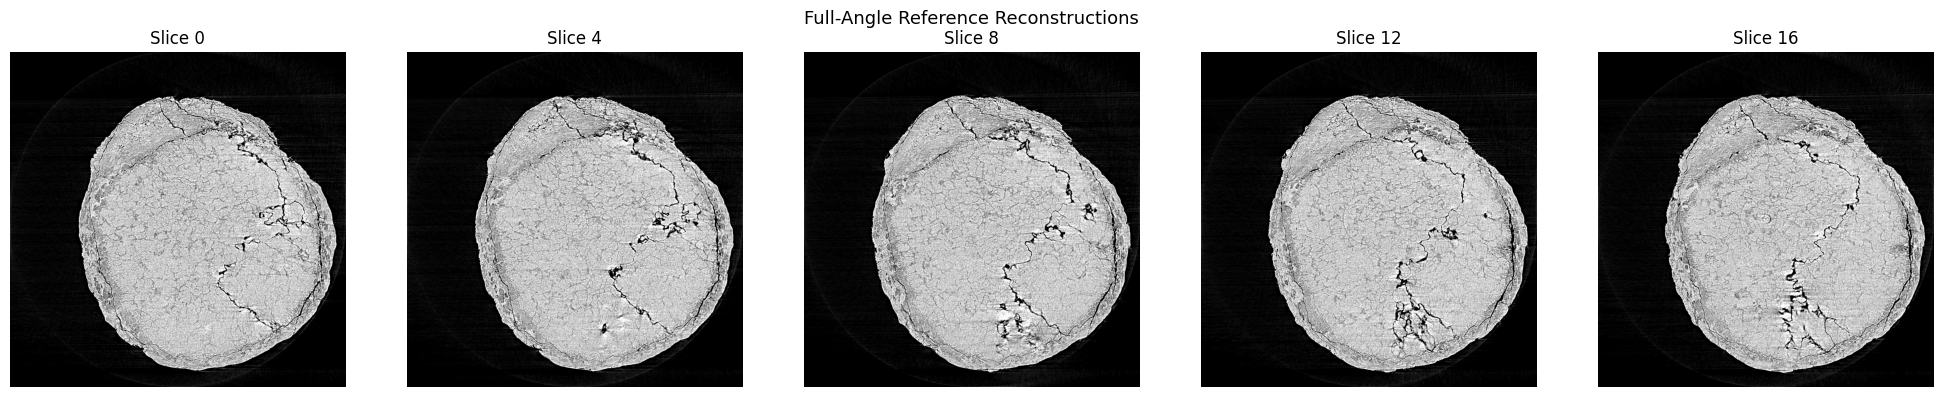

In [5]:
# ── Full-angle reference reconstructions (gradient-descent FBP) ───────────
vol_shape    = la_data.vol_shape       # (ny, nx)
vol_shape_3d = (1, *vol_shape)         # (1, ny, nx) for lamino projector

recon_3d = gd_reconstruction_masked(
    projs_vrc=la_data.full_sinograms.transpose(0, 1),   # (V_total, N_SLICES, W)
    angles_deg=la_data.all_angles_deg,
    lamino_angle_deg=LAMINO_ANGLE_DEG,
    vol_shape=(la_data.full_sinograms.shape[0],
               la_data.full_sinograms.shape[-1],
               la_data.full_sinograms.shape[-1]),
    det_spacing_mm=DET_SPACING_MM,
    batch_size=30,
    max_epochs=[5],
    lr=[0.5],
    vol_init=None,
    device=device,
    verbose=True,
)
full_recons = recon_3d.cpu()      # (N_SLICES, ny, nx)

n_show = min(5, N_SLICES)
fig, axes = plt.subplots(1, n_show, figsize=(4*n_show, 4))
for j in range(n_show):
    idx = j * (N_SLICES // n_show)
    img_arr = full_recons[idx].numpy()
    vmin, vmax = np.percentile(img_arr, [2, 98])
    axes[j].imshow(img_arr, cmap='gray', vmin=vmin, vmax=vmax)
    axes[j].set_title(f'Slice {idx}'); axes[j].axis('off')
plt.suptitle('Full-Angle Reference Reconstructions', fontsize=13)
plt.tight_layout(); plt.show()


Angle-slice mask: (1501, 20)
  Valid entries: 4,000 / 30,020 (13.3%)
  Angles per slice: [200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200]
  Measurements tensor: torch.Size([1501, 20, 1280])


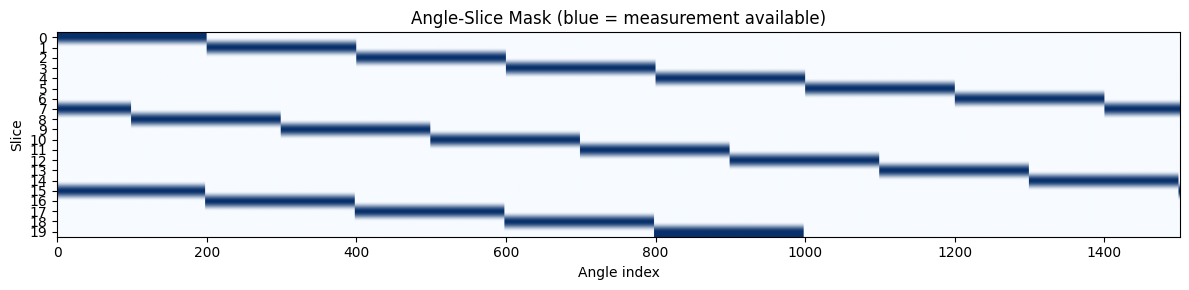

In [6]:
# ══════════════════════════════════════════════════════════════════════════
# Build angle-slice mask
# ══════════════════════════════════════════════════════════════════════════
# mask[v, t] = True iff slice t has a measurement at angle index v

V_total = len(la_data.all_angles_deg)
angle_slice_mask = torch.zeros(V_total, N_SLICES, dtype=torch.bool, device=device)
for t in range(N_SLICES):
    idx = la_data.slice_angle_indices[t]
    angle_slice_mask[idx, t] = True

n_valid = angle_slice_mask.sum().item()
n_total = V_total * N_SLICES
print(f"Angle-slice mask: ({V_total}, {N_SLICES})")
print(f"  Valid entries: {n_valid:,} / {n_total:,} ({100*n_valid/n_total:.1f}%)")
print(f"  Angles per slice: {angle_slice_mask.sum(dim=0).tolist()}")

# Full measurement tensor: (V_total, N_SLICES, W) for indexed access
# la_data.full_sinograms is (N_SLICES, V_total, W), permute to (V_total, N_SLICES, W)
meas_full_vrc = la_data.full_sinograms.to(device).permute(1, 0, 2).contiguous()
print(f"  Measurements tensor: {meas_full_vrc.shape}")

# Visualise the mask
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.imshow(angle_slice_mask.cpu().numpy().T, aspect='auto', cmap='Blues',
          extent=[0, V_total, N_SLICES-0.5, -0.5])
ax.set_xlabel('Angle index'); ax.set_ylabel('Slice')
ax.set_title('Angle-Slice Mask (blue = measurement available)')
ax.set_yticks(range(N_SLICES))
plt.tight_layout(); plt.show()

## 4. Helper Functions (Rendering, Projection, Densification)


In [7]:
# ── Metric helpers ────────────────────────────────────────────────────────
from skimage.metrics import structural_similarity as _sk_ssim

def compute_psnr(pred: np.ndarray, ref: np.ndarray) -> float:
    dr = float(ref.max() - ref.min())
    err = float(np.mean((pred - ref) ** 2))
    return 10 * math.log10(dr ** 2 / (err + 1e-12))

def compute_ssim(pred: np.ndarray, ref: np.ndarray) -> float:
    dr = float(ref.max() - ref.min())
    return float(_sk_ssim(ref, np.clip(pred, ref.min(), ref.max()), data_range=dr))


# ── Rasterise all slices → 3D volume (no clamping / no renormalisation) ───
def rasterise_volume(base_params, deltas_list, viewmat, K_cam, W_img, H_img, img_max, img_min):
    """Render every time-slice Gaussian state and stack into a volume.

    Returns
    -------
    volume : (N_slices, H_img, W_img) tensor — raw rendered values
    """
    slices = []
    for t in range(len(deltas_list)):
        params_t = apply_cumulative_deltas(base_params, deltas_list, t)
        rendered, _, _ = render(
            params_t.means, params_t.log_scales, params_t.quats,
            params_t.rgbs, params_t.opacities, viewmat, K_cam, W_img, H_img,
        )
        slices.append(rendered[:, :, 0])          # (H, W)
    
    image_3d = torch.stack(slices, dim=0)              # (N_slices, H, W)
    # Clamp to valid range
    image_3d = torch.clamp(image_3d, 0.0, 1.0)
    
    # Unnormalise to original intensity range for CT projection
    image_3d_unnorm = image_3d * (img_max - img_min) + img_min

    return image_3d_unnorm


# ── Cumulative-delta application ──────────────────────────────────────────
def apply_cumulative_deltas(base_params, deltas_list, t):
    cum = sum(deltas_list[: t + 1])
    return GaussianParams(
        means      = base_params.means      + cum[:, S_M],
        log_scales = base_params.log_scales + cum[:, S_S],
        quats      = base_params.quats      + cum[:, S_Q],
        rgbs       = base_params.rgbs       + cum[:, S_R],
        opacities  = base_params.opacities  + cum[:, S_O],
    )


# ── Adaptive densification (prune + split) ────────────────────────────────
def densify_gaussians(params, prune_thresh=0.005, split_thresh=10.0):
    with torch.no_grad():
        opac = torch.sigmoid(params.opacities)
        keep = opac > prune_thresh
        n_pruned = int((~keep).sum())

        me = params.means.data[keep].clone()
        ls = params.log_scales.data[keep].clone()
        qu = params.quats.data[keep].clone()
        rg = params.rgbs.data[keep].clone()
        op = params.opacities.data[keep].clone()

        split_mask = torch.exp(ls)[:, :2].max(1).values > split_thresh
        n_split = int(split_mask.sum())
        if n_split > 0:
            off = torch.zeros_like(me[split_mask])
            off[:, :2] = 0.5 * torch.exp(ls[split_mask][:, :2])
            keep2 = ~split_mask
            me = torch.cat([me[keep2], me[split_mask]+off, me[split_mask]-off], 0)
            ls = torch.cat([ls[keep2], ls[split_mask]-math.log(2), ls[split_mask]-math.log(2)], 0)
            qu = torch.cat([qu[keep2], qu[split_mask], qu[split_mask].clone()], 0)
            rg = torch.cat([rg[keep2], rg[split_mask], rg[split_mask].clone()], 0)
            op = torch.cat([op[keep2], op[split_mask], op[split_mask].clone()], 0)

    new_p = GaussianParams(me, ls, qu, rg, op).require_grad_()
    return new_p, n_pruned, n_split, keep, split_mask


def densify_with_deltas(params, deltas_list, prune_thresh=0.005, split_thresh=10.0):
    new_params, n_pruned, n_split, keep, split_mask = densify_gaussians(
        params, prune_thresh, split_thresh
    )
    new_deltas = []
    with torch.no_grad():
        for d in deltas_list:
            dk = d.data[keep].clone()
            if n_split > 0:
                dk = torch.cat([dk[~split_mask], dk[split_mask], dk[split_mask].clone()], 0)
            new_deltas.append(dk.requires_grad_(True))
    return new_params, new_deltas, n_pruned, n_split


# ── Optimiser builders ────────────────────────────────────────────────────
def build_base_optimizer(params, lr_dict=None):
    if lr_dict is None:
        lr_dict = dict(means=1e-3, log_scales=5e-3, quats=1e-3, rgbs=1e-2, opacities=5e-2)
    return optim.Adam([
        {"params": [params.means],      "lr": lr_dict['means']},
        {"params": [params.log_scales], "lr": lr_dict['log_scales']},
        {"params": [params.quats],      "lr": lr_dict['quats']},
        {"params": [params.rgbs],       "lr": lr_dict['rgbs']},
        {"params": [params.opacities],  "lr": lr_dict['opacities']},
    ], betas=(0.9, 0.999))

def build_joint_optimizer(base_params, deltas_list, lr_base, lr_delta):
    return optim.Adam([
        {"params": base_params.tensors(), "lr": lr_base},
        {"params": deltas_list,           "lr": lr_delta},
    ])

print("✅ Helpers defined")

✅ Helpers defined


## 5. Sinogram Masking Utilities & Progressive Window Schedule

The **training window** for slice *t* at epoch *e* is formed by pooling projections from
`half_current` neighbouring time slices on each side, where:

$$\text{half\_current}(e) = \left\lfloor \frac{n_{\text{win}}}{2} \cdot \max\!\left(0,\; 1 - \frac{e}{E_{\text{anneal}}}\right) \right\rfloor$$

At $e=0$: `n_win` slices are pooled — identical coverage to SW-FBP (~180°), using the
**actually acquired** `limited_sinograms` of neighbouring time slices at their own angles.
At $e \geq E_{\text{anneal}}$: only slice *t*'s own `limited_sinograms[t]` is used.

Critically, **no data is fabricated**: the only sinogram rows used at any epoch are those
in `la_data.limited_sinograms[tw]` for some `tw` in the pooling window.  The borrowed
rows correspond to projections acquired at different times but within the physical scan.
The function `get_active_sino(t, epoch)` returns both the stacked measurement tensor and

the corresponding angle indices into the V_total projector.

In [8]:
# ── Determine SW-FBP window size (min n_win slices to span ≥180°) ────────
# Use pure angle arithmetic: each slice covers K_ANGLES * angle_step degrees.
angle_step_deg      = float(la_data.all_angles_deg[1] - la_data.all_angles_deg[0])
angle_per_slice_deg = K_ANGLES * angle_step_deg
n_win               = math.ceil(180.0 / angle_per_slice_deg)
half_sw = n_win // 2


K_WIN    = n_win * K_ANGLES    # total projections in the wide window at epoch 0
E_ANNEAL = int(PM_ANNEAL_FRAC * PM_EPOCHS)

print(f"Angle step:          {angle_step_deg:.4f}°/proj")
print(f"Degrees per slice:   {angle_per_slice_deg:.2f}°")
print(f"SW window size:      n_win={n_win}  →  K_WIN={K_WIN} projections  "
      f"({K_WIN * angle_step_deg:.1f}° span)")
print(f"Anneal epochs:       {E_ANNEAL} / {PM_EPOCHS}  ({PM_ANNEAL_FRAC*100:.0f}%)")


Angle step:          0.1199°/proj
Degrees per slice:   23.98°
SW window size:      n_win=8  →  K_WIN=1600 projections  (191.9° span)
Anneal epochs:       800 / 800  (100%)


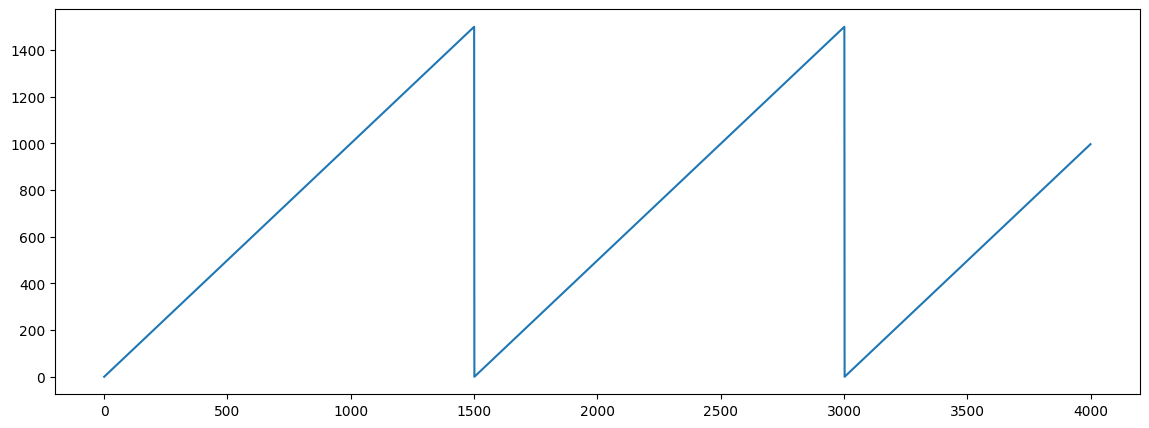

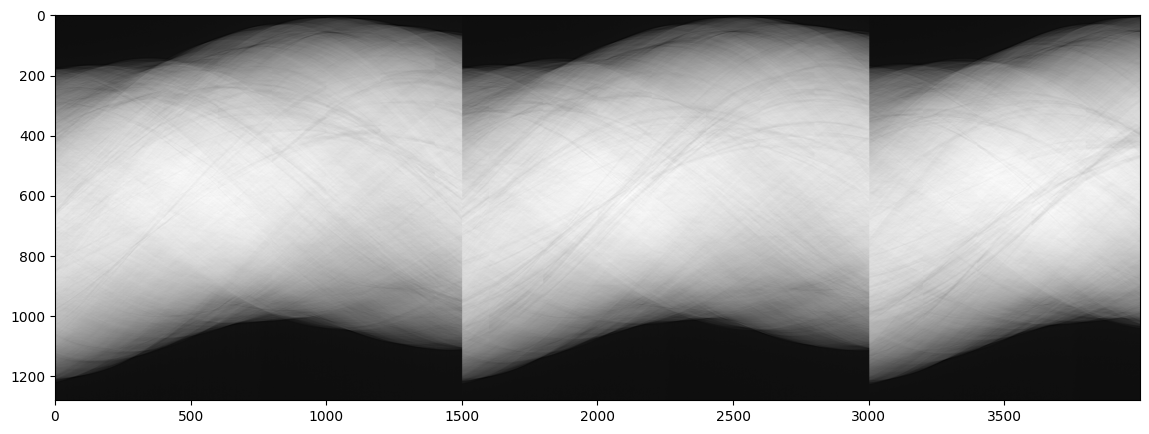

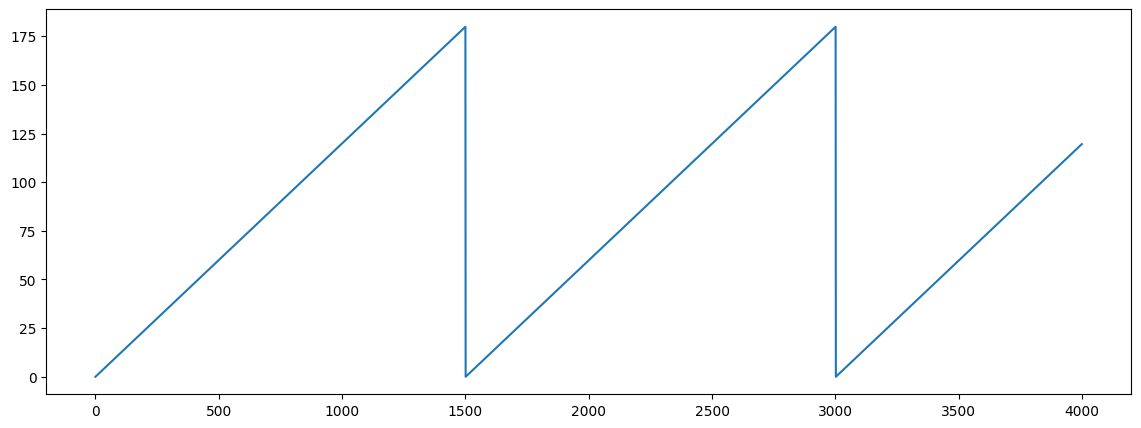

In [21]:

total_sino  = torch.zeros(K_ANGLES * N_SLICES, la_data.W)
total_idx = torch.zeros(K_ANGLES * N_SLICES)
total_angles = torch.zeros(K_ANGLES * N_SLICES)
centers = []
for t in range(N_SLICES):
    idx = la_data.slice_angle_indices[t]
    total_sino[t*K_ANGLES:(t+1)*K_ANGLES] = meas_full_vrc[idx, t]
    total_idx[t*K_ANGLES:(t+1)*K_ANGLES] = torch.from_numpy(idx)
    total_angles[t*K_ANGLES:(t+1)*K_ANGLES] = torch.from_numpy(la_data.all_angles_deg[idx])
    centers.append(K_ANGLES // 2 + t * K_ANGLES)


plt.plot(total_idx)
plt.figure()
plt.imshow(total_sino.T.cpu(), aspect='auto', cmap='gray')
plt.figure()
plt.plot(total_angles)


In [10]:

# ── Pre-build global measurement tensor (one sinogram row per angle) ──────
# Kept for legacy reference; get_active_sino no longer uses this.
# _global_meas uses last-writer semantics: when angles wrap around and
# multiple slices cover the same index, only the latest writer's data is
# kept — which is wrong for wrapping slices.
_global_meas = torch.zeros(V_total, la_data.W)
for _t in range(N_SLICES):
    _idx = np.asarray(la_data.slice_angle_indices[_t])
    _global_meas[_idx] = la_data.limited_sinograms[_t]

def get_active_sino(t: int, epoch: int, dev) -> tuple:
    """Return (sino_target, active_idx) for slice t at training epoch e.

    Mirrors the SW-FBP sliding-window construction used in pm_fbp_recons:
      epoch=0          → half_sw neighbours each side  (≈ SW-FBP, ~180°)
      epoch=PM_EPOCHS  → 0 neighbours                  (own slice only)
      Between          → linearly interpolated half-window size.

    Data always comes from la_data.limited_sinograms[tw] for each actual
    neighbour slice tw, accumulated and averaged for angles shared by
    multiple neighbours.  Slice-index wrap-around is handled via modulo,
    so slices near the boundary get correct data — no last-writer overwriting.

    Returns
    -------
    sino_target  : (k_active, W) tensor on `dev`
    active_idx   : (k_active,) LongTensor — row indices into the V_total projector
    """

    progress = min(1.0, epoch / max(PM_EPOCHS - 1, 1))
    sinogram_radius = (V_total - int((V_total - K_ANGLES) * progress)) // 2

    sino_img = total_sino[max(0, centers[t] - sinogram_radius) : min(total_sino.shape[0], centers[t] + sinogram_radius + 1)]
    idx_img = total_idx[max(0, centers[t] - sinogram_radius) : min(total_idx.shape[0], centers[t] + sinogram_radius + 1)]

    return sino_img.to(dev).float(), idx_img.long().to(dev)



In [11]:
# ══════════════════════════════════════════════════════════════════════════
# Visualise Progressive Window Scheduling
# ══════════════════════════════════════════════════════════════════════════
import ipywidgets as widgets
from ipywidgets import interact

def _build_progressive_mask(epoch: int) -> np.ndarray:
    """Build the (V_total × N_SLICES) active-angle mask at a given training epoch."""
    mask = np.zeros((V_total, N_SLICES), dtype=np.float32)
    for t in range(N_SLICES):
        _, active_idx = get_active_sino(t, epoch, dev='cpu')
        mask[active_idx.numpy(), t] = 1.0
    return mask

def _show_progressive_mask(epoch: int):
    mask = _build_progressive_mask(epoch)
    progress = min(1.0, epoch / max(PM_EPOCHS, 1))
    diameter = int(round(V_total + progress * (K_ANGLES - V_total)))
    diameter = max(K_ANGLES, min(V_total, diameter))

    fig, ax = plt.subplots(1, 1, figsize=(12, 3))
    ax.imshow(
        mask.T, aspect='auto', cmap='Blues',
        extent=[0, V_total, N_SLICES - 0.5, -0.5],
        vmin=0, vmax=1,
    )
    ax.set_xlabel('Angle index')
    ax.set_ylabel('Slice')
    ax.set_title(
        f'Progressive Window  —  Epoch {epoch}/{PM_EPOCHS}  |  '
        f'{diameter} proj/slice ({diameter*angle_step_deg:.1f}°)  '
        f'[{V_total}→{K_ANGLES} over {PM_EPOCHS} epochs]'
    )
    ax.set_yticks(range(N_SLICES))
    plt.tight_layout()
    plt.show()

interact(
    _show_progressive_mask,
    epoch=widgets.IntSlider(
        min=0,
        max=PM_EPOCHS,
        step=max(1, PM_EPOCHS // 200),
        value=0,
        description='Epoch',
        continuous_update=False,
        layout=widgets.Layout(width='80%'),
    ),
)


interactive(children=(IntSlider(value=0, continuous_update=False, description='Epoch', layout=Layout(width='80…

<function __main__._show_progressive_mask(epoch: int)>

## 5.5. PM-FBP: Epoch-Snapshot FBP via `get_active_sino`

FBP reconstruction using **exactly the projections returned by `get_active_sino`** at three
training checkpoints:

| Epoch | Coverage | Expected quality |
|-------|----------|-----------------|
| `0` | Full 180° (all V_total projections) | ≈ SW-FBP |
| `PM_EPOCHS // 2` | Intermediate window | Between SW-FBP and FBP-LA |
| `PM_EPOCHS - 1` | Own slice only (~K_ANGLES proj) | ≈ FBP-LA |

For each epoch a sparse `(V_total, W)` sinogram is built with zeros at inactive rows and
reconstructed with `fbp_reconstruction_masked` using the full angle vector.


In [12]:
# ── PM-FBP: variable-window SW-FBP that matches the PM training schedule ──
#
# Root-cause of earlier bugs:
#  1. _global_meas uses last-writer semantics → slice-0's angles can contain
#     measurements from slice 19 (different time, object may have changed).
#  2. At epoch 0, diameter=V_total → all angles active for every slice t
#     → same global sinogram → identical reconstruction for all slices.
#
# Fix: mirror get_active_sino's annealing in the NUMBER OF NEIGHBOURS used,
# exactly like SW-FBP but with a varying half-window:
#   epoch 0          → half_ep = half_sw  → n_win  neighbours  (= SW-FBP)
#   epoch PM_EPOCHS-1 → half_ep = 0        → 1 neighbour       (= FBP-LA)
# Data always comes from la_data.limited_sinograms[tw] with averaging.

pm_fbp_epoch_list = [0, PM_EPOCHS // 2, PM_EPOCHS - 1]
pm_fbp_recons  = {}
pm_fbp_psnrs   = {}
pm_fbp_ssims   = {}

for _ep in pm_fbp_epoch_list:
    _progress = min(1.0, _ep / max(PM_EPOCHS, 1))
    _half_ep  = int(round(half_sw * (1.0 - _progress)))   # half_sw → 0
    _n_win_ep = 2 * _half_ep + 1                           # n_win   → 1
    _recons   = []

    for _t in range(N_SLICES):
        _sw_sino  = torch.zeros(V_total, la_data.W)
        _sw_count = torch.zeros(V_total, 1)
        for _tw in [(_t - _half_ep + k) % N_SLICES for k in range(_n_win_ep)]:
            _ai = la_data.slice_angle_indices[_tw]
            _sw_sino[_ai]  += la_data.limited_sinograms[_tw]
            _sw_count[_ai] += 1.0
        _filled = _sw_count.squeeze() > 0
        _sw_sino[_filled] /= _sw_count[_filled]
        _recon = fbp_reconstruction_masked(
            projs_vrc=_sw_sino.to(device).unsqueeze(1),
            angles_deg=la_data.all_angles_deg,
            lamino_angle_deg=LAMINO_ANGLE_DEG,
            vol_shape=vol_shape_3d,
            det_spacing_mm=DET_SPACING_MM,
            filter_type='hann',
            device=device,
        )
        _recons.append(_recon[0].cpu())
    pm_fbp_recons[_ep] = torch.stack(_recons)
    print(f"PM-FBP  epoch {_ep:>{len(str(PM_EPOCHS))}d}  "
          f"(half_ep={_half_ep:2d}, {_n_win_ep} neighbours  ←  "
          f"{'= SW-FBP' if _n_win_ep == n_win else ('= FBP-LA' if _n_win_ep == 1 else 'intermediate')})")

print()

# ── Metrics ───────────────────────────────────────────────────────────────
for _ep in pm_fbp_epoch_list:
    _psnrs = [compute_psnr(pm_fbp_recons[_ep][i].numpy(), full_recons[i].numpy())
              for i in range(N_SLICES)]
    _ssims = [compute_ssim(pm_fbp_recons[_ep][i].numpy(), full_recons[i].numpy())
              for i in range(N_SLICES)]
    pm_fbp_psnrs[_ep] = _psnrs
    pm_fbp_ssims[_ep] = _ssims
    print(f"PM-FBP  epoch {_ep:>{len(str(PM_EPOCHS))}d}  →  "
          f"avg PSNR {float(np.mean(_psnrs)):6.2f} dB  |  avg SSIM {float(np.mean(_ssims)):.4f}")

# Sanity check: per-slice recons are distinct at all epochs
for _ep in pm_fbp_epoch_list:
    _r = pm_fbp_recons[_ep]
    _max_slice_diff = max(float((_r[i] - _r[0]).abs().max()) for i in range(1, N_SLICES))
    print(f"  epoch {_ep:>{len(str(PM_EPOCHS))}d}: max pixel diff across slices = {_max_slice_diff:.6f}  "
          f"{'✅ distinct' if _max_slice_diff > 1e-6 else '⚠️ IDENTICAL'}")


PM-FBP  epoch   0  (half_ep= 4, 9 neighbours  ←  intermediate)
PM-FBP  epoch 400  (half_ep= 2, 5 neighbours  ←  intermediate)
PM-FBP  epoch 799  (half_ep= 0, 1 neighbours  ←  = FBP-LA)

PM-FBP  epoch   0  →  avg PSNR  23.79 dB  |  avg SSIM 0.4712
PM-FBP  epoch 400  →  avg PSNR  19.84 dB  |  avg SSIM 0.4321
PM-FBP  epoch 799  →  avg PSNR  14.77 dB  |  avg SSIM 0.3249
  epoch   0: max pixel diff across slices = 0.004201  ✅ distinct
  epoch 400: max pixel diff across slices = 0.004169  ✅ distinct
  epoch 799: max pixel diff across slices = 0.002602  ✅ distinct


In [13]:
# ── PM-GD: variable-window SW-GD that matches the PM training schedule ──
#
# Root-cause of earlier bugs:
#  1. _global_meas uses last-writer semantics → slice-0's angles can contain
#     measurements from slice 19 (different time, object may have changed).
#  2. At epoch 0, diameter=V_total → all angles active for every slice t
#     → same global sinogram → identical reconstruction for all slices.
#
# Fix: mirror get_active_sino's annealing in the NUMBER OF NEIGHBOURS used,
# exactly like SW-FBP but with a varying half-window:
#   epoch 0          → half_ep = half_sw  → n_win  neighbours  (= SW-FBP)
#   epoch PM_EPOCHS-1 → half_ep = 0        → 1 neighbour       (= FBP-LA)
# Data always comes from la_data.limited_sinograms[tw] with averaging.

pm_fbp_epoch_list = [0, PM_EPOCHS // 2, PM_EPOCHS - 1]
pm_fbp_recons  = {}
pm_fbp_psnrs   = {}
pm_fbp_ssims   = {}

for _ep in pm_fbp_epoch_list:
    _progress = min(1.0, _ep / max(PM_EPOCHS, 1))
    _half_ep  = int(round(half_sw * (1.0 - _progress)))   # half_sw → 0
    _n_win_ep = 2 * _half_ep + 1                           # n_win   → 1
    _recons   = []

    for _t in range(N_SLICES):
        _sw_sino  = torch.zeros(V_total, la_data.W)
        _sw_count = torch.zeros(V_total, 1)
        for _tw in [(_t - _half_ep + k) % N_SLICES for k in range(_n_win_ep)]:
            _ai = la_data.slice_angle_indices[_tw]
            _sw_sino[_ai]  += la_data.limited_sinograms[_tw]
            _sw_count[_ai] += 1.0
        _filled = _sw_count.squeeze() > 0
        _sw_sino[_filled] /= _sw_count[_filled]
        _recon = fbp_reconstruction_masked(
            projs_vrc=_sw_sino.to(device).unsqueeze(1),
            angles_deg=la_data.all_angles_deg,
            lamino_angle_deg=LAMINO_ANGLE_DEG,
            vol_shape=vol_shape_3d,
            det_spacing_mm=DET_SPACING_MM,
            filter_type='hann',
            device=device,
        )

        # _recon = gd_reconstruction_masked(
        #     projs_vrc=_sw_sino.to(device).unsqueeze(1),
        #     angles_deg=la_data.all_angles_deg,
        #     lamino_angle_deg=LAMINO_ANGLE_DEG,
        #     vol_shape=vol_shape_3d,
        #     det_spacing_mm=DET_SPACING_MM,
        #     device=device,
        #     batch_size=30,
        #     max_epochs=[5],
        #     lr=[0.5],
        #     verbose=True,
        # )
        _recons.append(_recon[0].cpu())
    pm_fbp_recons[_ep] = torch.stack(_recons)
    print(f"PM-FBP  epoch {_ep:>{len(str(PM_EPOCHS))}d}  "
          f"(half_ep={_half_ep:2d}, {_n_win_ep} neighbours  ←  "
          f"{'= SW-FBP' if _n_win_ep == n_win else ('= FBP-LA' if _n_win_ep == 1 else 'intermediate')})")

print()

# ── Metrics ───────────────────────────────────────────────────────────────
for _ep in pm_fbp_epoch_list:
    _psnrs = [compute_psnr(pm_fbp_recons[_ep][i].numpy(), full_recons[i].numpy())
              for i in range(N_SLICES)]
    _ssims = [compute_ssim(pm_fbp_recons[_ep][i].numpy(), full_recons[i].numpy())
              for i in range(N_SLICES)]
    pm_fbp_psnrs[_ep] = _psnrs
    pm_fbp_ssims[_ep] = _ssims
    print(f"PM-FBP  epoch {_ep:>{len(str(PM_EPOCHS))}d}  →  "
          f"avg PSNR {float(np.mean(_psnrs)):6.2f} dB  |  avg SSIM {float(np.mean(_ssims)):.4f}")

# Sanity check: per-slice recons are distinct at all epochs
for _ep in pm_fbp_epoch_list:
    _r = pm_fbp_recons[_ep]
    _max_slice_diff = max(float((_r[i] - _r[0]).abs().max()) for i in range(1, N_SLICES))
    print(f"  epoch {_ep:>{len(str(PM_EPOCHS))}d}: max pixel diff across slices = {_max_slice_diff:.6f}  "
          f"{'✅ distinct' if _max_slice_diff > 1e-6 else '⚠️ IDENTICAL'}")


PM-FBP  epoch   0  (half_ep= 4, 9 neighbours  ←  intermediate)
PM-FBP  epoch 400  (half_ep= 2, 5 neighbours  ←  intermediate)
PM-FBP  epoch 799  (half_ep= 0, 1 neighbours  ←  = FBP-LA)

PM-FBP  epoch   0  →  avg PSNR  23.79 dB  |  avg SSIM 0.4712
PM-FBP  epoch 400  →  avg PSNR  19.84 dB  |  avg SSIM 0.4321
PM-FBP  epoch 799  →  avg PSNR  14.77 dB  |  avg SSIM 0.3249
  epoch   0: max pixel diff across slices = 0.004201  ✅ distinct
  epoch 400: max pixel diff across slices = 0.004169  ✅ distinct
  epoch 799: max pixel diff across slices = 0.002602  ✅ distinct


In [14]:
from ipywidgets import interact
@interact(epoch=pm_fbp_epoch_list, slice_idx=(0, pm_fbp_recons[0].shape[0] - 1))
def show_pm_fbp_recon(epoch: int = pm_fbp_epoch_list[0], slice_idx: int = 0):
    plt.imshow(pm_fbp_recons[epoch][slice_idx].numpy(), vmin=0)
    plt.colorbar()

interactive(children=(Dropdown(description='epoch', options=(0, 400, 799), value=0), IntSlider(value=0, descri…

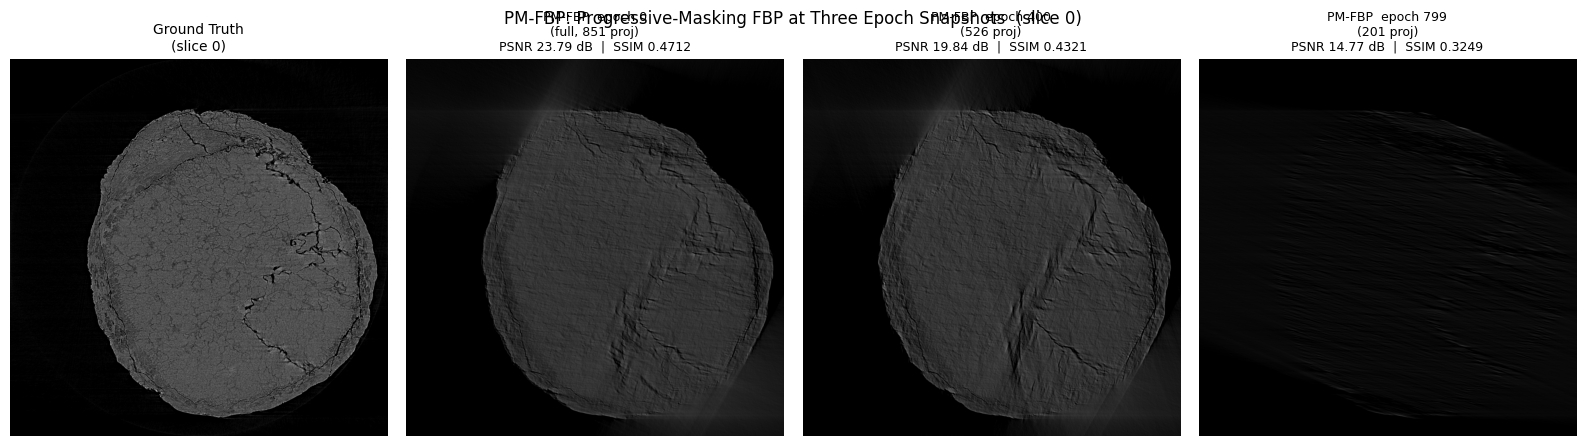

In [15]:
# ── Visualise PM-FBP reconstructions (middle slice) ──────────────────────
_slice_idx = 0
_n_cols = len(pm_fbp_epoch_list) + 1            # +1 for ground truth
_epoch_labels = {
    0:              f"epoch 0\n(full, {len(get_active_sino(0, 0, dev='cpu')[1])} proj)",
    PM_EPOCHS // 2: f"epoch {PM_EPOCHS // 2}\n({len(get_active_sino(0, PM_EPOCHS // 2, dev='cpu')[1])} proj)",
    PM_EPOCHS - 1:  f"epoch {PM_EPOCHS - 1}\n({len(get_active_sino(0, PM_EPOCHS - 1, dev='cpu')[1])} proj)",
}

fig, axes = plt.subplots(1, _n_cols, figsize=(4 * _n_cols, 4.5))

# Ground truth
_gt = full_recons[_slice_idx].numpy()
axes[0].imshow(_gt, cmap='gray', vmin=_gt.min(), vmax=_gt.max())
axes[0].set_title(f'Ground Truth\n(slice {_slice_idx})', fontsize=10)
axes[0].axis('off')

# PM-FBP at each epoch
for _col, _ep in enumerate(pm_fbp_epoch_list):
    _img = pm_fbp_recons[_ep][_slice_idx].numpy()
    _avg_psnr = float(np.mean(pm_fbp_psnrs[_ep]))
    _avg_ssim = float(np.mean(pm_fbp_ssims[_ep]))
    axes[_col + 1].imshow(_img, cmap='gray', vmin=_gt.min(), vmax=_gt.max())
    axes[_col + 1].set_title(
        f'PM-FBP  {_epoch_labels[_ep]}\n'
        f'PSNR {_avg_psnr:.2f} dB  |  SSIM {_avg_ssim:.4f}',
        fontsize=9,
    )
    axes[_col + 1].axis('off')

plt.suptitle(
    f'PM-FBP: Progressive-Masking FBP at Three Epoch Snapshots  (slice {_slice_idx})',
    fontsize=12,
)
plt.tight_layout()
plt.show()


## 6. Baselines: FBP-LA and SW-FBP


In [16]:
# ── FBP-LA: one FBP per slice using only its K_ANGLES projections ─────────
la_fbp_recons = []
for i in range(N_SLICES):
    sino  = la_data.limited_sinograms[i].to(device).unsqueeze(1)  # (K,1,W)
    recon = fbp_reconstruction_masked(
        projs_vrc=sino,
        angles_deg=la_data.slice_angles_deg[i],
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=vol_shape_3d,
        det_spacing_mm=DET_SPACING_MM,
        filter_type='hann',
        device=device,
    )
    la_fbp_recons.append(recon[0].cpu())
la_fbp_recons = torch.stack(la_fbp_recons)

la_fbp_psnrs = [compute_psnr(la_fbp_recons[i].numpy(), full_recons[i].numpy()) for i in range(N_SLICES)]
la_fbp_ssims = [compute_ssim(la_fbp_recons[i].numpy(), full_recons[i].numpy()) for i in range(N_SLICES)]
avg_la_psnr  = float(np.mean(la_fbp_psnrs))
avg_la_ssim  = float(np.mean(la_fbp_ssims))
print(f"FBP-LA  →  avg PSNR {avg_la_psnr:.2f} dB  |  avg SSIM {avg_la_ssim:.4f}")

# ── SW-FBP: sliding-window FBP using n_win slices per frame ──────────────
half_sw = n_win // 2
sw_fbp_recons = []
for t in range(N_SLICES):
    sw_sino  = torch.zeros(V_total, la_data.W)
    sw_count = torch.zeros(V_total, 1)
    for tw in [(t - half_sw + k) % N_SLICES for k in range(n_win)]:
        ai = la_data.slice_angle_indices[tw]
        sw_sino[ai]  += la_data.limited_sinograms[tw]
        sw_count[ai] += 1.0
    filled = sw_count.squeeze() > 0
    sw_sino[filled] /= sw_count[filled]
    recon = fbp_reconstruction_masked(
        projs_vrc=sw_sino.to(device).unsqueeze(1),
        angles_deg=la_data.all_angles_deg,
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=vol_shape_3d,
        det_spacing_mm=DET_SPACING_MM,
        filter_type='hann',
        device=device,
    )
    sw_fbp_recons.append(recon[0].cpu())
sw_fbp_recons = torch.stack(sw_fbp_recons)

sw_fbp_psnrs = [compute_psnr(sw_fbp_recons[i].numpy(), full_recons[i].numpy()) for i in range(N_SLICES)]
sw_fbp_ssims = [compute_ssim(sw_fbp_recons[i].numpy(), full_recons[i].numpy()) for i in range(N_SLICES)]
avg_sw_psnr  = float(np.mean(sw_fbp_psnrs))
avg_sw_ssim  = float(np.mean(sw_fbp_ssims))
print(f"SW-FBP  →  avg PSNR {avg_sw_psnr:.2f} dB  |  avg SSIM {avg_sw_ssim:.4f}  "
      f"(n_win={n_win})")


FBP-LA  →  avg PSNR 12.22 dB  |  avg SSIM 0.3291
SW-FBP  →  avg PSNR 23.49 dB  |  avg SSIM 0.4693  (n_win=8)


## 7. Initialization


In [17]:
# ── Reference image: slice 0 for Gaussian seeding ────────────────────────
ref_image_0      = full_recons[0]
ref_min, ref_max = float(ref_image_0.min()), float(ref_image_0.max())
ref_image_0_norm = (ref_image_0 - ref_min) / (ref_max - ref_min + 1e-8)
H_img, W_img     = ref_image_0_norm.shape

K_cam, viewmat = ortho_camera(device)

base_pm = init_gaussians(
    ref_image_0_norm, N_GAUSSIANS, device,
    mode=INIT_MODE, init_scale_px=INIT_SCALE_PX,
    init_opacity=0.3, seed=42,
).require_grad_()
print(f"Initialised {base_pm.n_gaussians:,} Gaussians  |  img ({H_img}×{W_img})")

# ── 3D volume / detector shapes for batched projection ───────────────────
vol_shape_3d_batch = (N_SLICES, *vol_shape)          # (N_SLICES, ny, nx)
det_shape_batch    = (N_SLICES, la_data.W)            # (N_SLICES, W)
print(f"3D volume shape: {vol_shape_3d_batch}  |  detector: {det_shape_batch}")

# ── Move global measurements to GPU for efficient batch look-up ───────────
_global_meas_dev = _global_meas.to(device).float()
print(f"Global measurements on {device}: {_global_meas_dev.shape}")

Initialised 400,689 Gaussians  |  img (1280×1280)
3D volume shape: (20, 1280, 1280)  |  detector: (20, 1280)
Global measurements on cuda: torch.Size([1501, 1280])


In [18]:
# ── Initialise Phase 2 parameters ────────────────────────────────────────
N_pm    = base_pm.n_gaussians
deltas_pm = [
    torch.zeros(N_pm, D_FULL, device=device, requires_grad=True)
    for _ in range(N_SLICES)
]
optimizer_pm = build_joint_optimizer(base_pm, deltas_pm, PM_LR_BASE, PM_LR_DELTA)

loss_history_pm   = []
psnr_history_pm   = {t: [] for t in range(N_SLICES)}
densify_epochs_pm = []

print(f"Phase 2 setup: N={N_pm:,}  |  {N_SLICES} slices  |  {PM_EPOCHS} epochs")
print(f"  Window anneals over {E_ANNEAL} epochs: K={K_WIN}→{K_ANGLES} per slice")
print(f"  Batch: {PM_BATCH_SIZE} angles/slice → union projector per iteration")
print(f"  Loss: masked MSE  +  λ_delta={PM_LAMBDA_DELTA}  λ_temporal={PM_LAMBDA_TEMPORAL}")

Phase 2 setup: N=400,689  |  20 slices  |  800 epochs
  Window anneals over 800 epochs: K=1600→200 per slice
  Batch: 50 angles/slice → union projector per iteration
  Loss: masked MSE  +  λ_delta=1e-05  λ_temporal=1e-05


## 8. Progressive-Mask Joint Optimisation (Batched 3D)

For each epoch *e*:
1. For each slice *t*, call `get_active_sino(t, e)` to obtain its progressive angle window.
2. Randomly **sub-sample** `PM_BATCH_SIZE` angles from each slice's window.
3. Collect the **union** of all sampled angles across all slices.
4. Build **one projector** for the union angles with `vol_shape = (N_SLICES, ny, nx)`.
5. Render all `N_SLICES` Gaussian states → stack as a 3D volume → project in a single call.
6. **Masked MSE loss**: each slice gets loss only from its own sampled angles — no fabricated data.

Raw rendered images are used directly (no [0, 1] clamping or renormalisation).

In [19]:
# ── Progressive-mask joint training ──────────────────────────────
PM_EPOCHS             = 1000       # total outer epochs
PM_LR_BASE            = 5e-3
PM_LR_DELTA           = 5e-3
PM_ANNEAL_FRAC        = 1.0      # fraction of epochs over which window shrinks
PM_BATCH_SIZE         = 50        # angles sampled per slice per iteration
PM_DENSIFY_FROM       = 20
PM_DENSIFY_INTERVAL   = 50
PM_DENSIFY_UNTIL      = 850
PM_PRUNE_THRESH       = 0.005
PM_SPLIT_THRESH       = 10.0
PM_LAMBDA_DELTA       = 1e-4
PM_LAMBDA_TEMPORAL    = 1e-4
PM_LAMBDA_ZERO_D0     = 1e-4

In [20]:
# ══════════════════════════════════════════════════════════════════════════
# Training: Batched 3D Progressive-Mask Joint Optimisation
# ══════════════════════════════════════════════════════════════════════════
t0_pm = time.time()

for epoch in range(PM_EPOCHS):

    # ── 1. Get active window indices per slice (progressive schedule) ─────
    active_per_slice = []
    target_sinograms_list = []
    for t in range(N_SLICES):
        sino_target, aidx = get_active_sino(t, epoch, dev=device)
        # sino_target, aidx = get_active_sino(t, 0, dev=device)
        # sino_target, aidx = get_active_sino(t, 100, dev=device)
        active_per_slice.append(aidx)                       # (k_active,) long
        target_sinograms_list.append(sino_target)          # (k_active, W) float
    # ── 2. Sub-sample PM_BATCH_SIZE angles per slice ──────────────────────
    sampled_per_slice = []
    permutations = []
    for t in range(N_SLICES):
        active = active_per_slice[t]
        k = min(PM_BATCH_SIZE, len(active))
        perm = torch.randperm(len(active), device=device)[:k].sort().values
        sampled_per_slice.append(active[perm])
        permutations.append(perm)

    # ── 3. Union of all sampled angle indices ─────────────────────────────
    union_angles_idx = torch.unique(torch.cat(sampled_per_slice))  # sorted
    n_union = len(union_angles_idx)

    # ── 4. Build ONE projector for the union angles ───────────────────────
    union_angles_deg = la_data.all_angles_deg[union_angles_idx.cpu().numpy()]
    projector_batch = build_lamino_projector(
        vol_shape=vol_shape_3d_batch,
        det_shape=det_shape_batch,
        angles_deg=union_angles_deg,
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        voxel_size_mm=VOXEL_SIZE_MM,
        det_spacing_mm=DET_SPACING_MM,
        device=device,
    )
    # ── 5. Render all slices → 3D volume → project ───────────────────────
    optimizer_pm.zero_grad(set_to_none=True)

    volume_3d = rasterise_volume(                           # (N_SLICES, H, W)
        base_pm, deltas_pm, viewmat, K_cam, W_img, H_img, recon_3d.max(), recon_3d.min()
    )
    vol_in = volume_3d.unsqueeze(0).unsqueeze(0)            # (1, 1, N_SLICES, H, W)
    pred_sino = projector_batch(vol_in)[0]                  # (n_union, N_SLICES, W)

    data_loss = 0.0
    # ── 7. Build per-slice mask: (n_union, N_SLICES) ─────────────────────
    for t in range(N_SLICES):
        positions = torch.searchsorted(union_angles_idx, sampled_per_slice[t]) # positions within pred_sino interesting for slice t
        data_loss += F.mse_loss(pred_sino[positions, t], target_sinograms_list[t][permutations[t]])

    # # ── 9. Regularisation (all slices at once) ────────────────────────────
    # delta_stack = torch.stack(deltas_pm)                    # (N_SLICES, N_pm, D_FULL)
    # reg_d = PM_LAMBDA_DELTA  * torch.mean(delta_stack ** 2)
    # reg_0 = PM_LAMBDA_ZERO_D0 * torch.mean(deltas_pm[0] ** 2)
    # reg_t = PM_LAMBDA_TEMPORAL * torch.mean((delta_stack[1:] - delta_stack[:-1]) ** 2)

    loss = data_loss# + reg_d + reg_0 + reg_t
    loss.backward()
    optimizer_pm.step()

    loss_history_pm.append(loss.item())

    # ── Adaptive densification ────────────────────────────────────────────
    if (PM_DENSIFY_FROM <= epoch < PM_DENSIFY_UNTIL
            and epoch % PM_DENSIFY_INTERVAL == 0 and epoch > 0):
        base_pm, deltas_pm, n_pr, n_sp = densify_with_deltas(
            base_pm, deltas_pm, PM_PRUNE_THRESH, PM_SPLIT_THRESH)
        N_pm = base_pm.n_gaussians
        optimizer_pm = build_joint_optimizer(base_pm, deltas_pm, PM_LR_BASE, PM_LR_DELTA)
        # Refresh GPU measurements pointer (unchanged, but keeps scope clear)
        _global_meas_dev = _global_meas.to(device).float()
        densify_epochs_pm.append(epoch)
        print(f"  ↳ densify @{epoch}: pruned={n_pr} split={n_sp} N={N_pm:,}")

    # ── Per-epoch PSNR (every 5 epochs) ──────────────────────────────────
    if (epoch + 1) % 5 == 0 or epoch == 0:
        with torch.no_grad():
            slice_psnrs_ep = []
            volume_3d_full = rasterise_volume(                           # (N_SLICES, H, W)
                base_pm, deltas_pm, viewmat, K_cam, W_img, H_img, recon_3d.max(), recon_3d.min()
            )

            for t in range(N_SLICES):
                img_t = volume_3d_full[t, :, :].cpu().numpy()
                ref_t = full_recons[t].numpy()
                p_ep = compute_psnr(img_t, ref_t)
                psnr_history_pm[t].append(p_ep)
                slice_psnrs_ep.append(p_ep)

        avg_ep = float(np.mean(slice_psnrs_ep))
        print(f"  Epoch {epoch+1:4d}/{PM_EPOCHS} | "
              f"loss={loss.item():.6f}  data={data_loss.item():.6f} | "
              f"avg PSNR={avg_ep:.2f} dB  "
              f"[{min(slice_psnrs_ep):.1f}–{max(slice_psnrs_ep):.1f}] | "
              f"n_union={n_union}  N={N_pm:,}")

elapsed_pm = time.time() - t0_pm
print(f"\n✅ Progressive-mask training done in {elapsed_pm:.1f}s")

Output()

KeyboardInterrupt: 

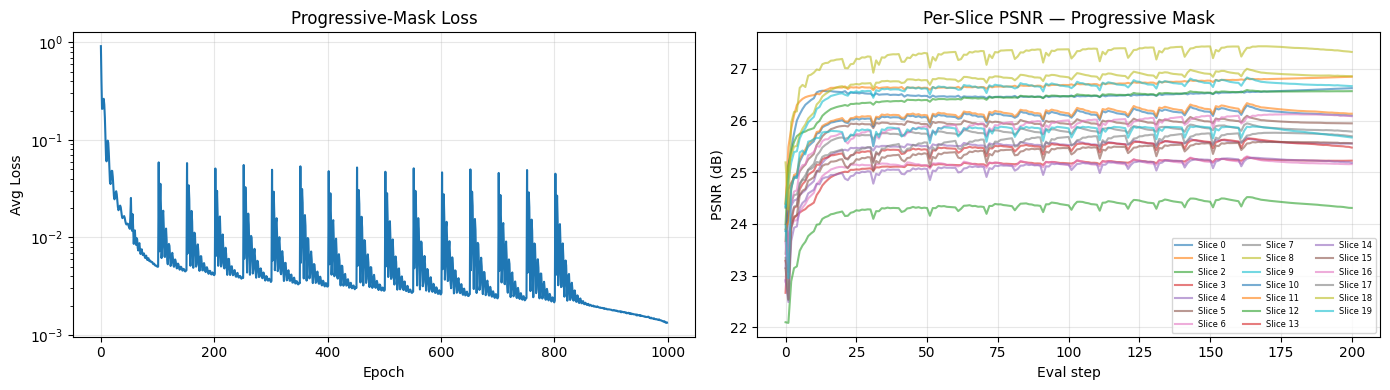

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].semilogy(loss_history_pm); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Avg Loss'); axes[0].set_title('Progressive-Mask Loss')
axes[0].grid(True, alpha=0.3)

for t in range(N_SLICES):
    if psnr_history_pm[t]:
        axes[1].plot(psnr_history_pm[t], alpha=0.6, label=f'Slice {t}')
axes[1].set_xlabel('Eval step'); axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Per-Slice PSNR — Progressive Mask')
axes[1].legend(fontsize=6, ncol=3); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Extract Final Reconstructions


In [ ]:
# ── Rasterise final Gaussians for every slice ─────────────────────────────
pm_recons = []
pm_psnrs  = []
pm_ssims  = []

with torch.no_grad():
    volume_3d_full = rasterise_volume(
        base_pm, deltas_pm, viewmat, K_cam, W_img, H_img, recon_3d.max(), recon_3d.min()
    )  # (N_SLICES, H, W)
    for t in range(N_SLICES):
        
        img_t = volume_3d_full[t, :, :].cpu()    # raw rendered — no clamping / renorm

        pm_recons.append(img_t)
        ref_t = full_recons[t].numpy()
        pm_psnrs.append(compute_psnr(img_t.numpy(), ref_t))
        pm_ssims.append(compute_ssim(img_t.numpy(), ref_t))

pm_recons = torch.stack(pm_recons)
avg_pm_psnr = float(np.mean(pm_psnrs))
avg_pm_ssim = float(np.mean(pm_ssims))
print(f"Progressive-Mask GSplat  →  avg PSNR {avg_pm_psnr:.2f} dB  |  avg SSIM {avg_pm_ssim:.4f}")

Progressive-Mask GSplat  →  avg PSNR 25.94 dB  |  avg SSIM 0.6418


## 10. Visual Comparison: Ground Truth vs FBP-LA vs SW-FBP vs Progressive-Mask GSplat


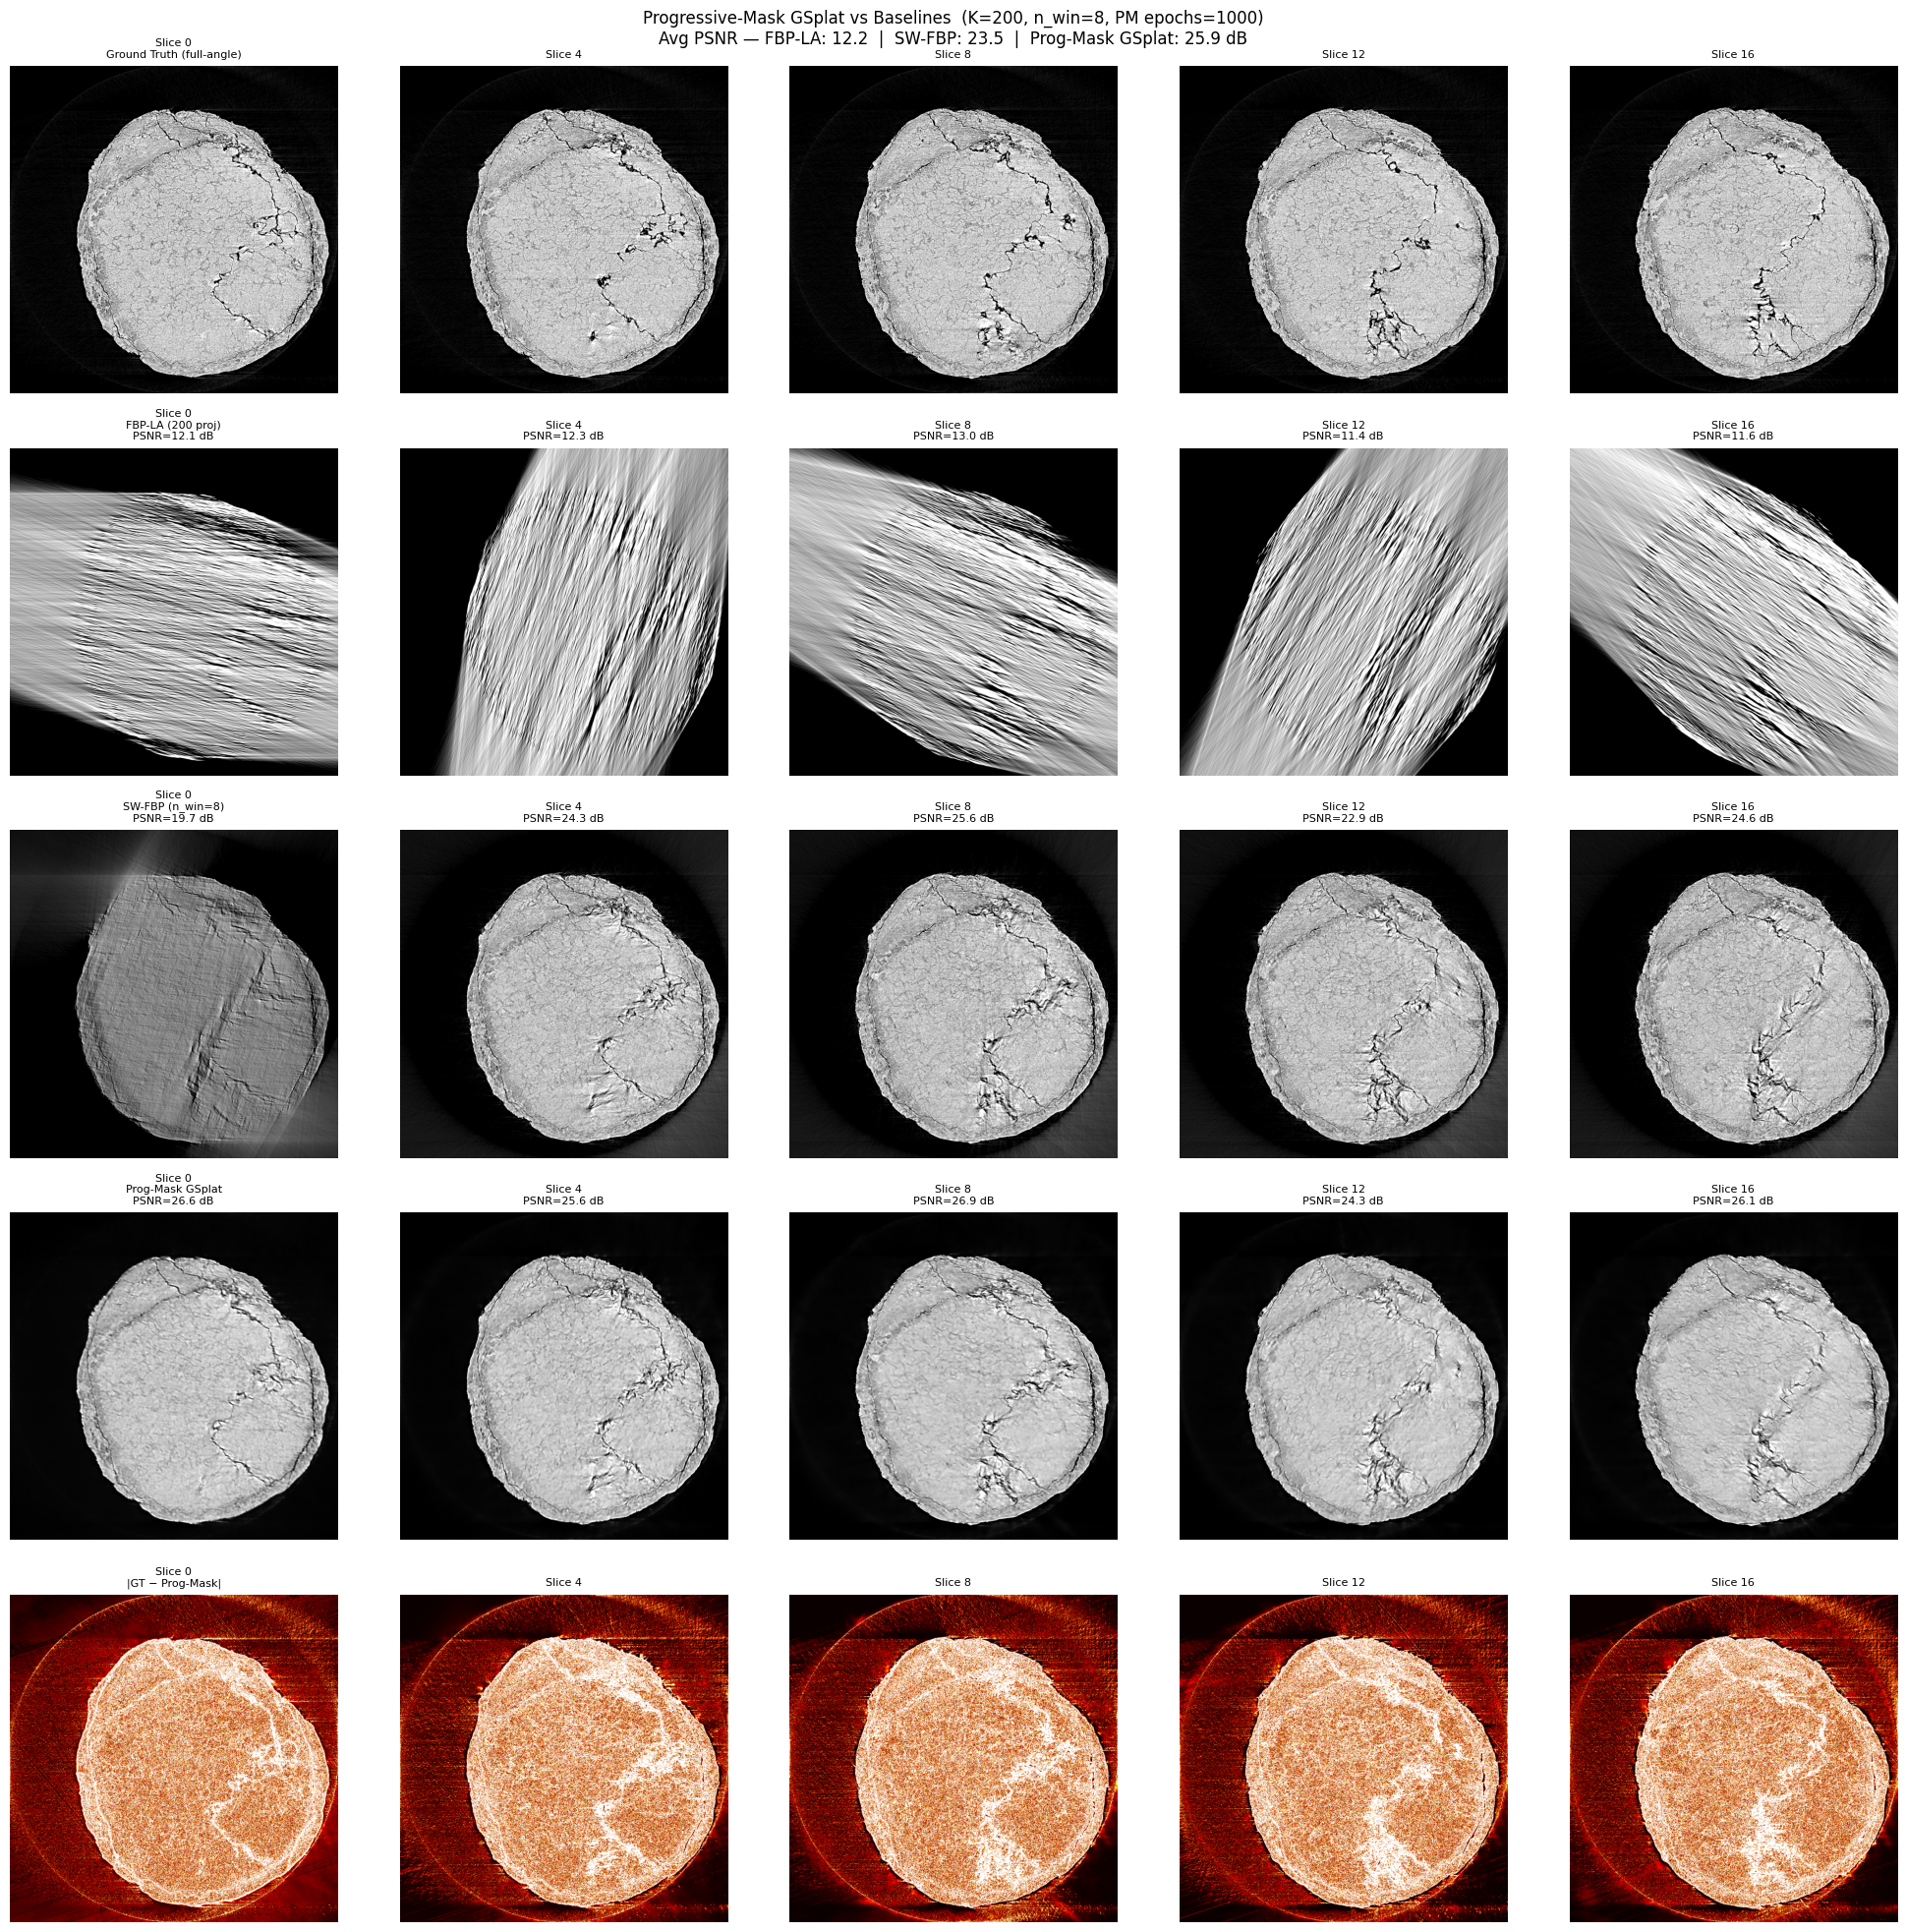

In [ ]:
n_show  = min(5, N_SLICES)
n_rows  = 5   # GT / FBP-LA / SW-FBP / PM-GSplat / difference map

fig, axes = plt.subplots(n_rows, n_show, figsize=(4 * n_show, 4 * n_rows))
row_titles = [
    'Ground Truth (full-angle)',
    f'FBP-LA ({K_ANGLES} proj)',
    f'SW-FBP (n_win={n_win})',
    f'Prog-Mask GSplat',
    '|GT − Prog-Mask|',
]

for j in range(n_show):
    idx  = j * (N_SLICES // n_show) if n_show < N_SLICES else j
    ref  = full_recons[idx].numpy()
    vmin, vmax = np.percentile(ref, [2, 98])

    images = [
        ref,
        la_fbp_recons[idx].numpy(),
        sw_fbp_recons[idx].numpy(),
        pm_recons[idx].numpy(),
        np.abs(ref - pm_recons[idx].numpy()),
    ]
    cmaps  = ['gray', 'gray', 'gray', 'gray', 'hot']
    vmins  = [vmin,  vmin,  vmin,  vmin,  0]
    vmaxs  = [vmax,  vmax,  vmax,  vmax,  (vmax - vmin) * 0.1]

    psnr_labels = [
        '',
        f'PSNR={la_fbp_psnrs[idx]:.1f} dB',
        f'PSNR={sw_fbp_psnrs[idx]:.1f} dB',
        f'PSNR={pm_psnrs[idx]:.1f} dB',
        '',
    ]

    for row in range(n_rows):
        ax = axes[row, j]
        ax.imshow(images[row], cmap=cmaps[row], vmin=vmins[row], vmax=vmaxs[row])
        title = f'Slice {idx}\n{row_titles[row]}' if j == 0 else f'Slice {idx}'
        if psnr_labels[row]:
            title += f'\n{psnr_labels[row]}'
        ax.set_title(title, fontsize=8)
        ax.axis('off')

plt.suptitle(
    f'Progressive-Mask GSplat vs Baselines  '
    f'(K={K_ANGLES}, n_win={n_win}, PM epochs={PM_EPOCHS})\n'
    f'Avg PSNR — FBP-LA: {avg_la_psnr:.1f}  |  SW-FBP: {avg_sw_psnr:.1f}  |  '
    f'Prog-Mask GSplat: {avg_pm_psnr:.1f} dB',
    fontsize=12,
)
plt.tight_layout()
plt.show()


In [ ]:
from ipywidgets import interact
@interact(slice_idx=(0, pm_fbp_recons[0].shape[0] - 1))
def show_pm_fbp_recon(slice_idx: int = 0):
    # show two imgaes side by side: FBP-LA and PM-GSplat
    fig, axes = plt.subplots(1, 3, figsize=(20, 10))
    
    axes[0].imshow(sw_fbp_recons[slice_idx].cpu().clip(0, 1).numpy(), cmap='gray')
    axes[0].axis('off') 
    axes[1].imshow(pm_recons[slice_idx].cpu().detach().numpy(), cmap='gray')
    axes[1].set_title(f'Prog-Mask GSplat  (PSNR {pm_psnrs[slice_idx]:.2f} dB)')
    axes[2].imshow(full_recons[slice_idx].cpu().numpy(), cmap='gray')
    axes[2].set_title('Ground Truth')
    plt.tight_layout()
    plt.show()
    

interactive(children=(IntSlider(value=0, description='slice_idx', max=19), Output()), _dom_classes=('widget-in…

## 11. Quantitative Metrics (PSNR, SSIM)


In [ ]:
# ── Per-slice summary table ───────────────────────────────────────────────
header = (f"{'Slice':>6}  "
          f"{'FBP-LA':>10}  {'SW-FBP':>10}  {'PM-GSplat':>10}  "
          f"{'Δ(PM-LA)':>9}  {'Δ(PM-SW)':>9}  "
          f"{'SSIM-LA':>9}  {'SSIM-SW':>9}  {'SSIM-PM':>9}")
print(header)
print("-" * len(header))

for i in range(N_SLICES):
    print(f"{i:>6d}  "
          f"{la_fbp_psnrs[i]:>10.2f}  {sw_fbp_psnrs[i]:>10.2f}  {pm_psnrs[i]:>10.2f}  "
          f"{pm_psnrs[i]-la_fbp_psnrs[i]:>+9.2f}  {pm_psnrs[i]-sw_fbp_psnrs[i]:>+9.2f}  "
          f"{la_fbp_ssims[i]:>9.4f}  {sw_fbp_ssims[i]:>9.4f}  {pm_ssims[i]:>9.4f}")

print("-" * len(header))
print(f"{'AVG':>6}  "
      f"{avg_la_psnr:>10.2f}  {avg_sw_psnr:>10.2f}  {avg_pm_psnr:>10.2f}  "
      f"{avg_pm_psnr-avg_la_psnr:>+9.2f}  {avg_pm_psnr-avg_sw_psnr:>+9.2f}  "
      f"{np.mean(la_fbp_ssims):>9.4f}  {np.mean(sw_fbp_ssims):>9.4f}  {avg_pm_ssim:>9.4f}")


 Slice      FBP-LA      SW-FBP   PM-GSplat   Δ(PM-LA)   Δ(PM-SW)    SSIM-LA    SSIM-SW    SSIM-PM
-------------------------------------------------------------------------------------------------
     0       12.12       19.68       26.63     +14.51      +6.95     0.3391     0.3854     0.6441
     1       11.78       20.10       26.85     +15.07      +6.75     0.3069     0.4310     0.6632
     2       11.94       22.33       26.57     +14.63      +4.24     0.3276     0.4446     0.6569
     3       11.23       23.18       25.23     +14.00      +2.04     0.3506     0.4274     0.6250
     4       12.34       24.33       25.56     +13.21      +1.23     0.3421     0.4774     0.6356
     5       13.38       24.67       25.95     +12.57      +1.28     0.3291     0.4968     0.6488
     6       12.33       23.91       25.16     +12.83      +1.25     0.3108     0.4876     0.6324
     7       12.45       24.60       25.79     +13.34      +1.19     0.3450     0.5081     0.6472
     8       13.05  

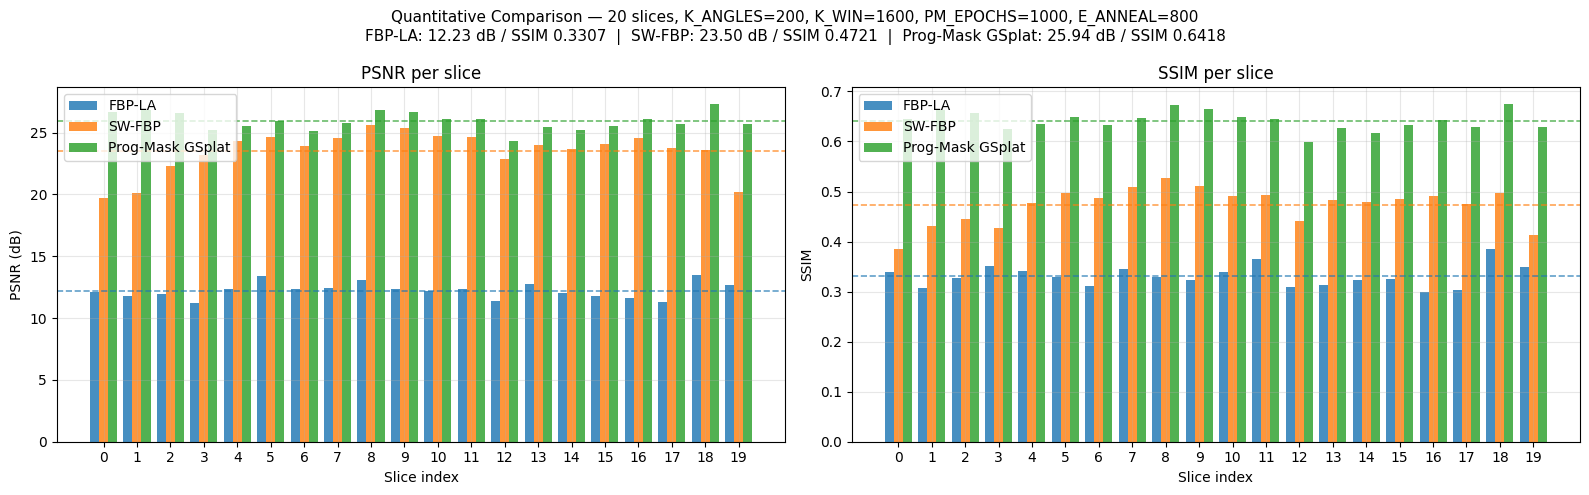

In [ ]:
# ── Bar chart: PSNR & SSIM per slice ─────────────────────────────────────
x = np.arange(N_SLICES)
w = 0.27

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# PSNR
axes[0].bar(x - w, la_fbp_psnrs, w, label='FBP-LA',           alpha=0.82, color='C0')
axes[0].bar(x,     sw_fbp_psnrs, w, label='SW-FBP',           alpha=0.82, color='C1')
axes[0].bar(x + w, pm_psnrs,     w, label='Prog-Mask GSplat', alpha=0.82, color='C2')
axes[0].axhline(avg_la_psnr,  color='C0', ls='--', lw=1.2, alpha=0.7)
axes[0].axhline(avg_sw_psnr,  color='C1', ls='--', lw=1.2, alpha=0.7)
axes[0].axhline(avg_pm_psnr,  color='C2', ls='--', lw=1.2, alpha=0.7)
axes[0].set_xticks(x); axes[0].set_xlabel('Slice index')
axes[0].set_ylabel('PSNR (dB)'); axes[0].set_title('PSNR per slice')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# SSIM
axes[1].bar(x - w, la_fbp_ssims, w, label='FBP-LA',           alpha=0.82, color='C0')
axes[1].bar(x,     sw_fbp_ssims, w, label='SW-FBP',           alpha=0.82, color='C1')
axes[1].bar(x + w, pm_ssims,     w, label='Prog-Mask GSplat', alpha=0.82, color='C2')
axes[1].axhline(float(np.mean(la_fbp_ssims)), color='C0', ls='--', lw=1.2, alpha=0.7)
axes[1].axhline(float(np.mean(sw_fbp_ssims)), color='C1', ls='--', lw=1.2, alpha=0.7)
axes[1].axhline(avg_pm_ssim,                  color='C2', ls='--', lw=1.2, alpha=0.7)
axes[1].set_xticks(x); axes[1].set_xlabel('Slice index')
axes[1].set_ylabel('SSIM'); axes[1].set_title('SSIM per slice')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'Quantitative Comparison — {N_SLICES} slices, K_ANGLES={K_ANGLES}, K_WIN={K_WIN}, '
    f'PM_EPOCHS={PM_EPOCHS}, E_ANNEAL={E_ANNEAL}\n'
    f'FBP-LA: {avg_la_psnr:.2f} dB / SSIM {np.mean(la_fbp_ssims):.4f}  |  '
    f'SW-FBP: {avg_sw_psnr:.2f} dB / SSIM {np.mean(sw_fbp_ssims):.4f}  |  '
    f'Prog-Mask GSplat: {avg_pm_psnr:.2f} dB / SSIM {avg_pm_ssim:.4f}',
    fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:

volume_3d = torch.zeros((N_SLICES, H_img, W_img), device=device)  # (N_SLICES, H, W)
volume_3d.requires_grad_(True)
optimizer_pm = optim.Adam([volume_3d], lr=1e-4)

# ══════════════════════════════════════════════════════════════════════════
# Training: Batched 3D Progressive-Mask Joint Optimisation
# ══════════════════════════════════════════════════════════════════════════
t0_pm = time.time()

for epoch in range(PM_EPOCHS):

    # ── 1. Get active window indices per slice (progressive schedule) ─────
    active_per_slice = []
    target_sinograms_list = []
    for t in range(N_SLICES):
        sino_target, aidx = get_active_sino(t, epoch, dev=device)
        # sino_target, aidx = get_active_sino(t, 0, dev=device)
        # sino_target, aidx = get_active_sino(t, 100, dev=device)
        active_per_slice.append(aidx)                       # (k_active,) long
        target_sinograms_list.append(sino_target)          # (k_active, W) float
    # ── 2. Sub-sample PM_BATCH_SIZE angles per slice ──────────────────────
    sampled_per_slice = []
    permutations = []
    for t in range(N_SLICES):
        active = active_per_slice[t]
        k = min(PM_BATCH_SIZE, len(active))
        perm = torch.randperm(len(active), device=device)[:k].sort().values
        sampled_per_slice.append(active[perm])
        permutations.append(perm)

    # ── 3. Union of all sampled angle indices ─────────────────────────────
    union_angles_idx = torch.unique(torch.cat(sampled_per_slice))  # sorted
    n_union = len(union_angles_idx)

    # ── 4. Build ONE projector for the union angles ───────────────────────
    union_angles_deg = la_data.all_angles_deg[union_angles_idx.cpu().numpy()]
    projector_batch = build_lamino_projector(
        vol_shape=vol_shape_3d_batch,
        det_shape=det_shape_batch,
        angles_deg=union_angles_deg,
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        voxel_size_mm=VOXEL_SIZE_MM,
        det_spacing_mm=DET_SPACING_MM,
        device=device,
    )
    # ── 5. Render all slices → 3D volume → project ───────────────────────
    optimizer_pm.zero_grad(set_to_none=True)

    vol_in = volume_3d.unsqueeze(0).unsqueeze(0)            # (1, 1, N_SLICES, H, W)
    pred_sino = projector_batch(vol_in)[0]                  # (n_union, N_SLICES, W)

    data_loss = 0.0
    # ── 7. Build per-slice mask: (n_union, N_SLICES) ─────────────────────
    for t in range(N_SLICES):
        positions = torch.searchsorted(union_angles_idx, sampled_per_slice[t]) # positions within pred_sino interesting for slice t
        data_loss += F.mse_loss(pred_sino[positions, t], target_sinograms_list[t][permutations[t]])

    # ── 9. Regularisation (all slices at once) ────────────────────────────
    delta_stack = torch.stack(deltas_pm)                    # (N_SLICES, N_pm, D_FULL)
    reg_d = PM_LAMBDA_DELTA  * torch.mean(delta_stack ** 2)
    reg_0 = PM_LAMBDA_ZERO_D0 * torch.mean(deltas_pm[0] ** 2)
    reg_t = PM_LAMBDA_TEMPORAL * torch.mean((delta_stack[1:] - delta_stack[:-1]) ** 2)

    loss = data_loss + reg_d + reg_0 + reg_t
    loss.backward()
    optimizer_pm.step()

    loss_history_pm.append(loss.item())

    # ── Per-epoch PSNR (every 5 epochs) ──────────────────────────────────
    if (epoch + 1) % 5 == 0 or epoch == 0:
        with torch.no_grad():
            slice_psnrs_ep = []

            for t in range(N_SLICES):
                img_t = volume_3d[t, :, :].cpu().numpy()
                ref_t = full_recons[t].numpy()
                p_ep = compute_psnr(img_t, ref_t)
                psnr_history_pm[t].append(p_ep)
                slice_psnrs_ep.append(p_ep)

        avg_ep = float(np.mean(slice_psnrs_ep))
        print(f"  Epoch {epoch+1:4d}/{PM_EPOCHS} | "
              f"loss={loss.item():.6f}  data={data_loss.item():.6f} | "
              f"avg PSNR={avg_ep:.2f} dB  "
              f"[{min(slice_psnrs_ep):.1f}–{max(slice_psnrs_ep):.1f}] | "
              f"n_union={n_union}  N={N_pm:,}")

elapsed_pm = time.time() - t0_pm
print(f"\n✅ Progressive-mask training done in {elapsed_pm:.1f}s")

  Epoch    1/1000 | loss=17.909151  data=17.909151 | avg PSNR=14.38 dB  [12.9–15.9] | n_union=737  N=400,689
  Epoch    5/1000 | loss=5.676127  data=5.676126 | avg PSNR=16.42 dB  [15.0–18.0] | n_union=734  N=400,689
  Epoch   10/1000 | loss=2.137914  data=2.137913 | avg PSNR=17.29 dB  [15.8–19.2] | n_union=753  N=400,689
  Epoch   15/1000 | loss=2.041059  data=2.041058 | avg PSNR=18.54 dB  [17.1–20.3] | n_union=712  N=400,689
  Epoch   20/1000 | loss=0.865259  data=0.865259 | avg PSNR=20.56 dB  [17.4–22.0] | n_union=726  N=400,689
  Epoch   25/1000 | loss=0.247302  data=0.247301 | avg PSNR=21.63 dB  [17.4–23.2] | n_union=746  N=400,689
  Epoch   30/1000 | loss=0.393959  data=0.393958 | avg PSNR=21.78 dB  [17.9–23.4] | n_union=740  N=400,689
  Epoch   35/1000 | loss=0.258438  data=0.258437 | avg PSNR=22.41 dB  [18.5–24.2] | n_union=723  N=400,689
  Epoch   40/1000 | loss=0.097224  data=0.097223 | avg PSNR=23.02 dB  [18.8–24.7] | n_union=736  N=400,689
  Epoch   45/1000 | loss=0.110765  

In [ ]:
from ipywidgets import interact
@interact(slice_idx=(0, pm_fbp_recons[0].shape[0] - 1))
def show_pm_fbp_recon(slice_idx: int = 0):
    plt.imshow(volume_3d[slice_idx].cpu().detach().numpy(), vmin=0)
    plt.colorbar()

interactive(children=(IntSlider(value=0, description='slice_idx', max=19), Output()), _dom_classes=('widget-in…